In [2]:
# ============================================================
# Setup
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/brain_tumor_classification')

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from pathlib import Path
from collections import defaultdict

# ── Project paths
PROJECT_ROOT = '/content/drive/MyDrive/brain_tumor_classification'
TRAIN_DIR    = os.path.join(PROJECT_ROOT, 'data', 'Training')
TEST_DIR     = os.path.join(PROJECT_ROOT, 'data', 'Testing')
CLASSES      = ['glioma', 'meningioma', 'notumor', 'pituitary']

# ── Plot styling
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print("Setup complete. Starting EDA...")
print(f"  Training dir : {TRAIN_DIR}")
print(f"  Testing dir  : {TEST_DIR}")
print(f"  Classes      : {CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Starting EDA...
  Training dir : /content/drive/MyDrive/brain_tumor_classification/data/Training
  Testing dir  : /content/drive/MyDrive/brain_tumor_classification/data/Testing
  Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']



  Images per class:
  Training/glioma          1400 images
  Testing/glioma          400 images
  Training/meningioma      1400 images
  Testing/meningioma      400 images
  Training/notumor         1400 images
  Testing/notumor         400 images
  Training/pituitary       1400 images
  Testing/pituitary       400 images


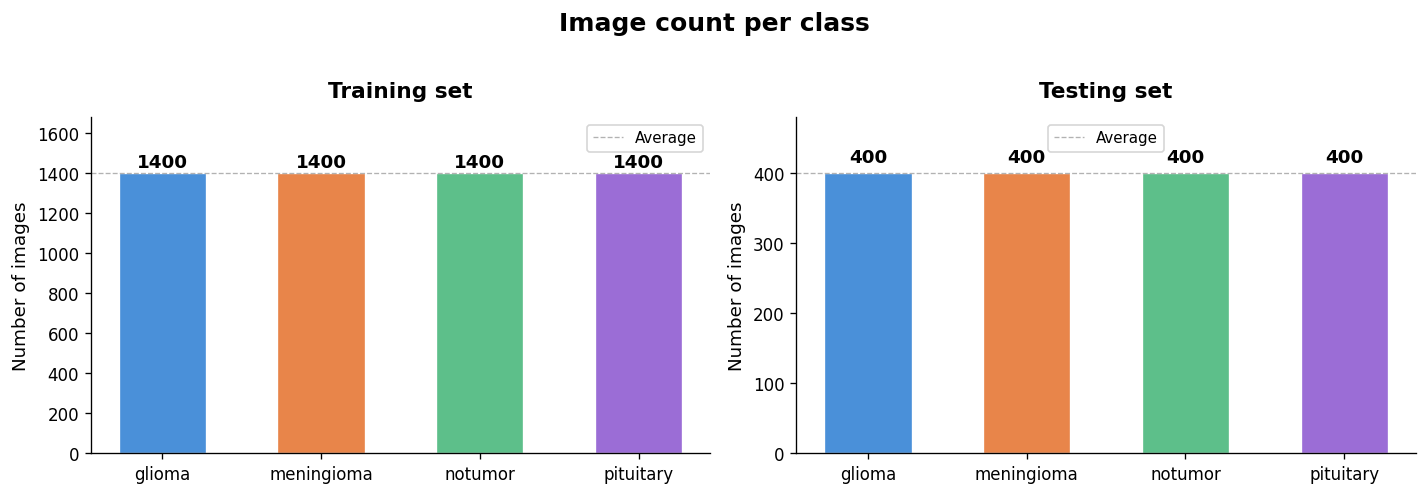


  Chart saved to outputs/eda_class_distribution.png


In [3]:
# ============================================================
# Image counts per class
# ============================================================
print("\n" + "="*50)
print("  Images per class:")
print("="*50)

# Count images in each split/class
counts = {'Training': {}, 'Testing': {}}

for cls in CLASSES:
    for split, split_dir in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
        folder = os.path.join(split_dir, cls)
        images = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        counts[split][cls] = len(images)
        print(f"  {split}/{cls:<15} {len(images)} images")

# ── Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4A90D9', '#E8854A', '#5DBF8A', '#9B6DD6']

for ax, (split, split_counts) in zip(axes, counts.items()):
    bars = ax.bar(
        CLASSES,
        split_counts.values(),
        color=colors,
        width=0.55,
        edgecolor='white',
        linewidth=0.8
    )
    # Add count labels on top of each bar
    for bar, val in zip(bars, split_counts.values()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            str(val),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )
    ax.set_title(f'{split} set', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Number of images', fontsize=11)
    ax.set_ylim(0, max(split_counts.values()) * 1.2)
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, fontsize=10)
    ax.axhline(
        y=sum(split_counts.values()) / len(split_counts),
        color='gray', linestyle='--', linewidth=0.8, alpha=0.6,
        label='Average'
    )
    ax.legend(fontsize=9)

plt.suptitle('Image count per class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_ROOT, 'outputs', 'eda_class_distribution.png'),
    bbox_inches='tight', dpi=150
)
plt.show()
print("\n  Chart saved to outputs/eda_class_distribution.png")


  MRI images: 


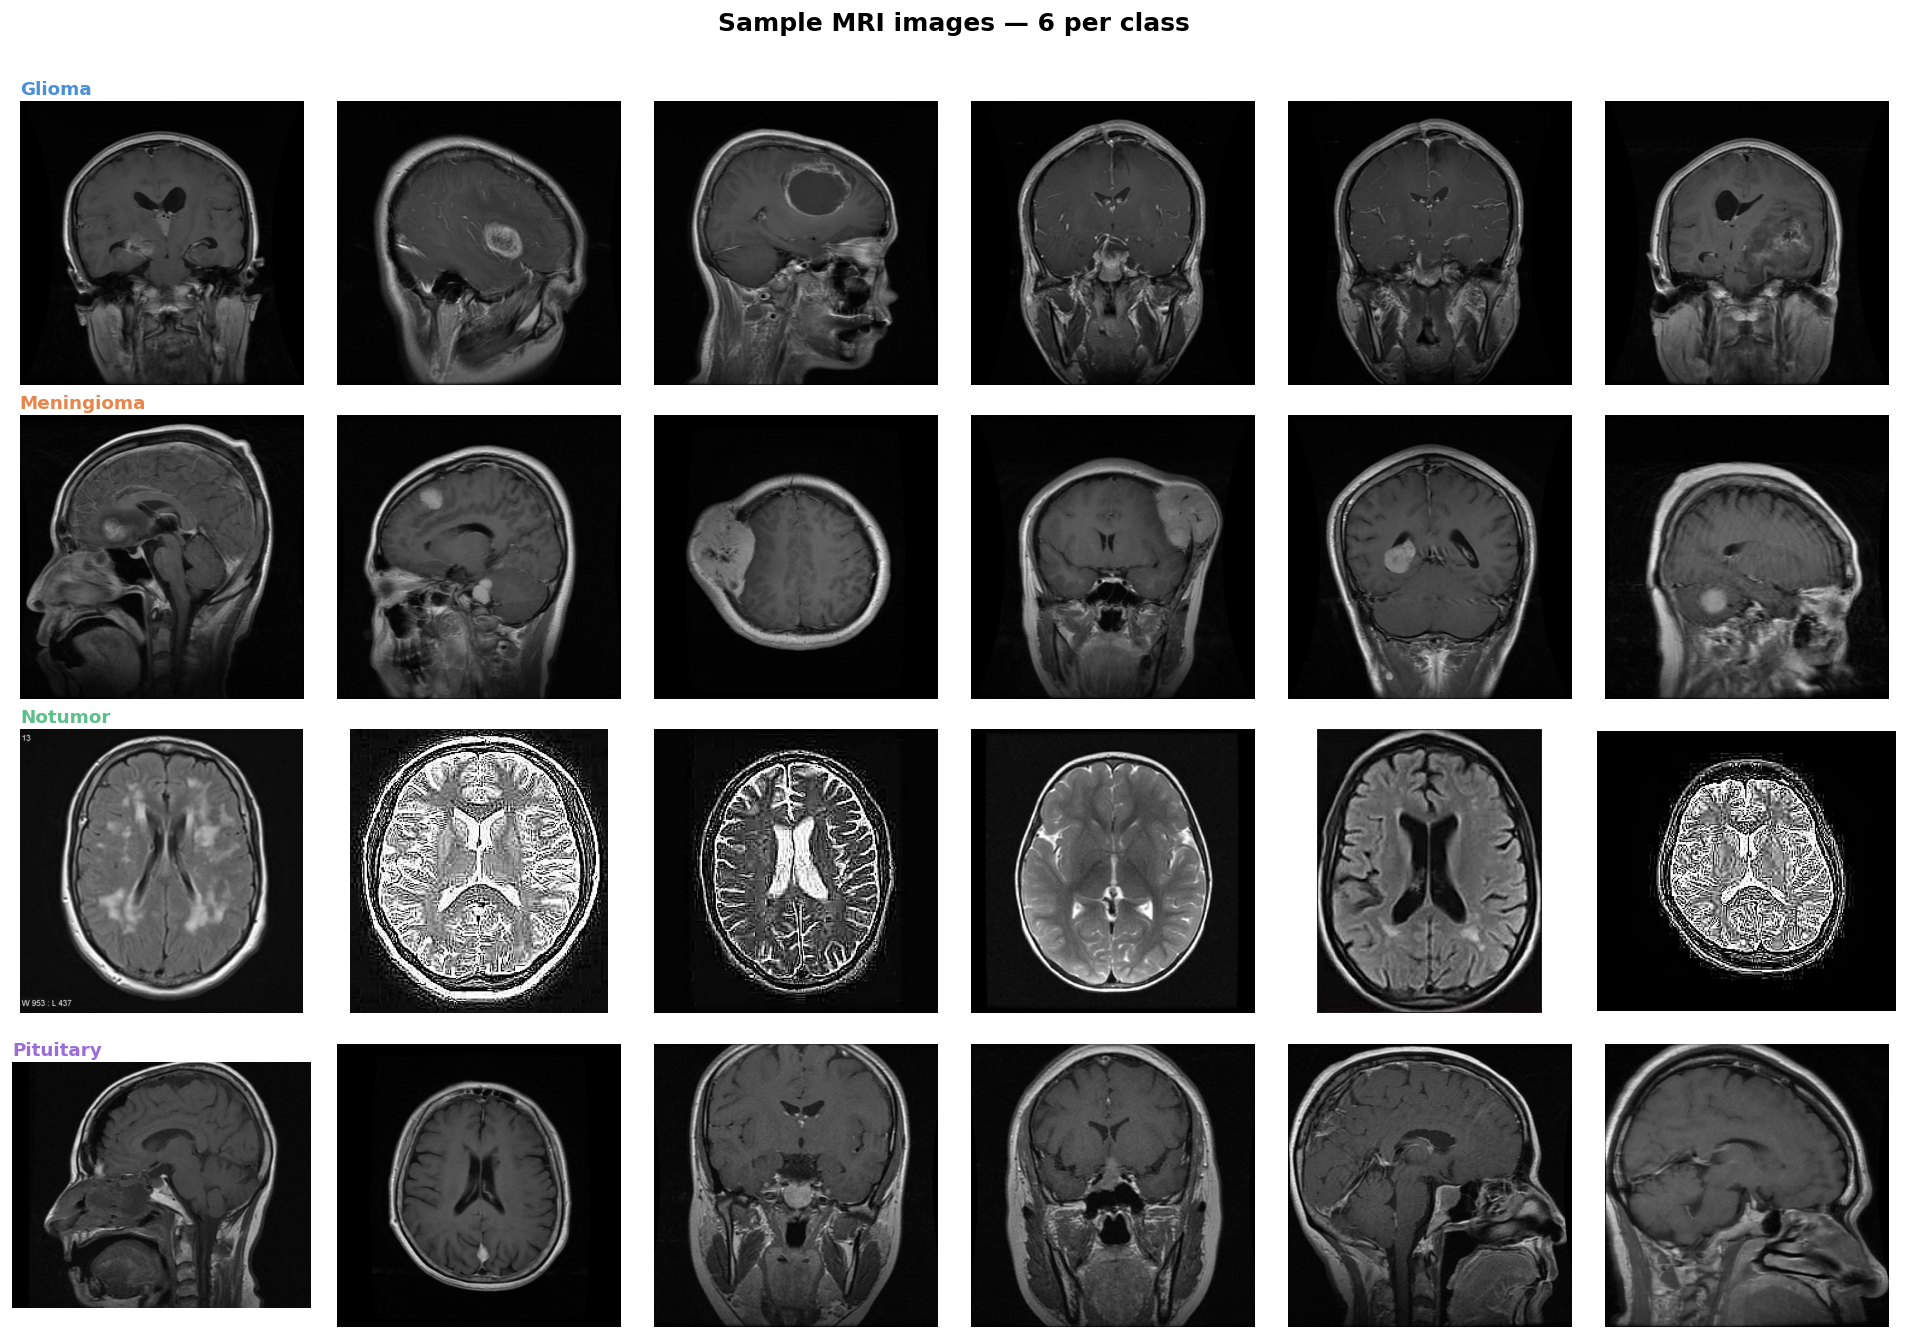

  Sample grid saved to outputs/eda_sample_images.png


In [7]:
# ============================================================
# Visulization of MRI Images
# ============================================================
print("\n" + "="*50)
print("  MRI images: ")
print("="*50)

import random
random.seed(42)

fig, axes = plt.subplots(4, 6, figsize=(16, 11))
fig.suptitle('Sample MRI images — 6 per class', fontsize=15, fontweight='bold', y=1.01)

class_colors = {
    'glioma':      '#4A90D9',
    'meningioma':  '#E8854A',
    'notumor':     '#5DBF8A',
    'pituitary':   '#9B6DD6',
}

for row, cls in enumerate(CLASSES):
    folder  = os.path.join(TRAIN_DIR, cls)
    images  = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(6, len(images)))

    for col, img_file in enumerate(samples):
        ax  = axes[row][col]
        img = Image.open(os.path.join(folder, img_file)).convert('RGB')
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.axis('off')

        # Class label on the first image of each row
        if col == 0:
            ax.set_title(
                cls.capitalize(),
                fontsize=11, fontweight='bold',
                color=class_colors[cls],
                loc='left', pad=4
            )

plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_ROOT, 'outputs', 'eda_MRI_sample_Images_per_Class.png'),
    bbox_inches='tight', dpi=300
)
plt.show()
print("  Sample grid saved to outputs/eda_sample_images.png")


  Consistency of Image sizes:
  Scanning image dimensions (this takes ~1 minute)...

  Class             Min W   Max W   Avg W   Min H   Max H   Avg H
  ------------------------------------------------------------
  glioma              512     512     512     512     512     512
  meningioma          180    1275     495     207    1427     497
  notumor             150    1375     313     168    1446     327
  pituitary           201    1365     513     202    1365     512


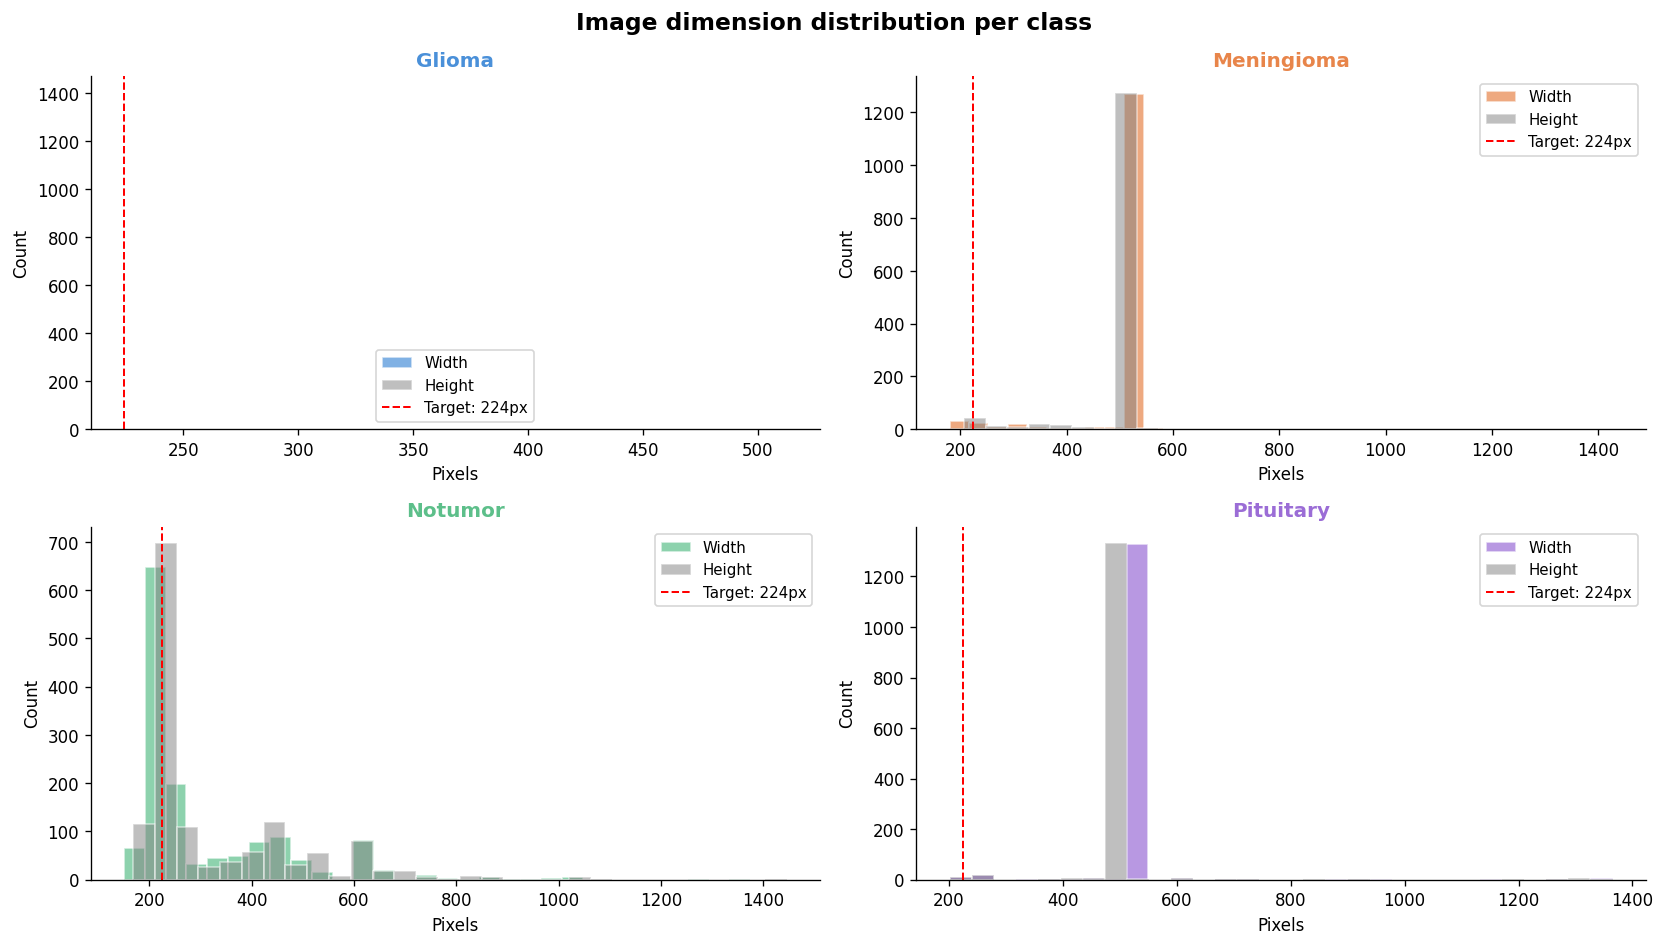


  Overall size range: width 150–1375px, height 168–1446px
  Size chart saved to outputs/eda_image_sizes.png


In [8]:
# ============================================================
#  Verification of consistency of Image sizes
# ============================================================
print("\n" + "="*50)
print("  Consistency of Image sizes:")
print("="*50)

widths  = defaultdict(list)
heights = defaultdict(list)

print("  Scanning image dimensions (this takes ~1 minute)...")

for cls in CLASSES:
    folder = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in images:
        try:
            img = Image.open(os.path.join(folder, img_file))
            w, h = img.size
            widths[cls].append(w)
            heights[cls].append(h)
        except Exception:
            pass  # Corrupt files handled in Cell 5

# ── Print summary statistics
print(f"\n  {'Class':<15} {'Min W':>7} {'Max W':>7} {'Avg W':>7} {'Min H':>7} {'Max H':>7} {'Avg H':>7}")
print("  " + "-" * 60)
for cls in CLASSES:
    w_list = widths[cls]
    h_list = heights[cls]
    print(
        f"  {cls:<15}"
        f" {min(w_list):>7}"
        f" {max(w_list):>7}"
        f" {int(sum(w_list)/len(w_list)):>7}"
        f" {min(h_list):>7}"
        f" {max(h_list):>7}"
        f" {int(sum(h_list)/len(h_list)):>7}"
    )

# ── Histogram of widths and heights
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Image dimension distribution per class', fontsize=14, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    ax  = axes[idx // 2][idx % 2]
    color = colors[idx]

    ax.hist(widths[cls],  bins=30, alpha=0.7, color=color,  label='Width',  edgecolor='white')
    ax.hist(heights[cls], bins=30, alpha=0.5, color='gray', label='Height', edgecolor='white')

    ax.axvline(x=224, color='red', linestyle='--', linewidth=1.2, label='Target: 224px')
    ax.set_title(cls.capitalize(), fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Pixels', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(PROJECT_ROOT, 'outputs', 'eda_image_sizes.png'),
    bbox_inches='tight', dpi=300
)
plt.show()

# ── Recommendation
all_widths  = [w for wlist in widths.values()  for w in wlist]
all_heights = [h for hlist in heights.values() for h in hlist]
print(f"\n  Overall size range: width {min(all_widths)}–{max(all_widths)}px, height {min(all_heights)}–{max(all_heights)}px")
#print("  Recommendation: resize all images to 224x224 before training.")
print("  Size chart saved to outputs/eda_image_sizes.png")

In [9]:
# ============================================================
#  Checking for corrupt files:
# ============================================================
print("\n" + "="*50)
print("  Corrupt or unreadable files:")
print("="*50)

corrupt_files = []
total_scanned = 0

for split, split_dir in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
    for cls in CLASSES:
        folder = os.path.join(split_dir, cls)
        images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for img_file in images:
            total_scanned += 1
            path = os.path.join(folder, img_file)
            try:
                img = Image.open(path)
                img.verify()  # Checks file integrity without fully loading
            except Exception as e:
                corrupt_files.append({'path': path, 'error': str(e)})

print(f"  Total files scanned : {total_scanned}")
print(f"  Corrupt files found : {len(corrupt_files)}")

if corrupt_files:
    print("\n  Corrupt files:")
    for f in corrupt_files:
        print(f"    {f['path']}")
        print(f"    Error: {f['error']}")
else:
    print("  All files are readable — no corrupt images found.")


  Corrupt or unreadable files:
  Total files scanned : 7200
  Corrupt files found : 0
  All files are readable — no corrupt images found.


In [11]:
# ============================================================
#  CELL 6 — EDA Summary
# ============================================================
print("\n" + "="*50)
print("  EDA Summary:")
print("="*50)

total_train = sum(counts['Training'].values())
total_test  = sum(counts['Testing'].values())

print(f"""
  Dataset overview:
  ─────────────────────────────────────────
  Total training images : {total_train}
  Total testing images  : {total_test}
  Number of classes     : {len(CLASSES)}
  Classes               : {', '.join(CLASSES)}
  Class balance         : {'Balanced' if max(counts['Training'].values()) - min(counts['Training'].values()) < 50 else 'Imbalanced'}

  Image sizes:
  ─────────────────────────────────────────
  Sizes vary across the dataset
  Recommendation: resize to 224x224

  Data quality:
  ─────────────────────────────────────────
  Corrupt files         : {len(corrupt_files)}
  Ready for training    : {'YES' if len(corrupt_files) == 0 else 'NO — fix corrupt files first'}

  Saved outputs:
  ─────────────────────────────────────────
  outputs/eda_class_distribution.png
  outputs/eda_sample_images.png
  outputs/eda_image_sizes.png
  ─────────────────────────────────────────

  EDA complete.
""")


  EDA Summary:

  Dataset overview:
  ─────────────────────────────────────────
  Total training images : 5600
  Total testing images  : 1600
  Number of classes     : 4
  Classes               : glioma, meningioma, notumor, pituitary
  Class balance         : Balanced

  Image sizes:
  ─────────────────────────────────────────
  Sizes vary across the dataset
  Recommendation: resize to 224x224

  Data quality:
  ─────────────────────────────────────────
  Corrupt files         : 0
  Ready for training    : YES

  Saved outputs:
  ─────────────────────────────────────────
  outputs/eda_class_distribution.png
  outputs/eda_sample_images.png
  outputs/eda_image_sizes.png
  ─────────────────────────────────────────

  EDA complete.

